# NLMS Adaptive Filter

NLMS (Normalised LMS) divides the step size by the instantaneous input power at each sample:

```
μ_eff[n] = μ / (ε + ‖x[n]‖²)
```

This makes the convergence rate **independent of input level**, unlike plain LMS where a louder input can cause divergence without retuning μ. The small constant ε prevents division by zero during silence.

| Function | Description |
| --- | --- |
| `nlms` | Normalised LMS (NLMS) adaptive FIR filter. Returns `(output, error, weights)`. |


In [1]:
import sys
sys.path.insert(0, '../src')

import numpy as np
import matplotlib.pyplot as plt

from python.adaptive import lms, nlms
from python.generators import generate_sine, generate_white_noise

FS = 44100

%matplotlib inline
plt.rcParams['figure.dpi'] = 110

## Visualisation

NLMS vs LMS noise-cancellation comparison on an 880 Hz sine with 50 % noise (order = 32).

**Three-panel stack (300 ms window):**
- **Top — NLMS error:** converges to the misadjustment floor approximately twice as fast as LMS at the same μ
- **Middle — LMS error:** slower convergence; noise remains audible longer in the output
- **Bottom — RMS error over time (both algorithms):** NLMS (solid) reaches −20 dB noticeably earlier than LMS (dashed)

Because the NLMS step size automatically scales with input power, the same μ = 0.5 works reliably across a wide dynamic range. LMS at μ = 0.002 is set conservatively to avoid instability at this noise level.


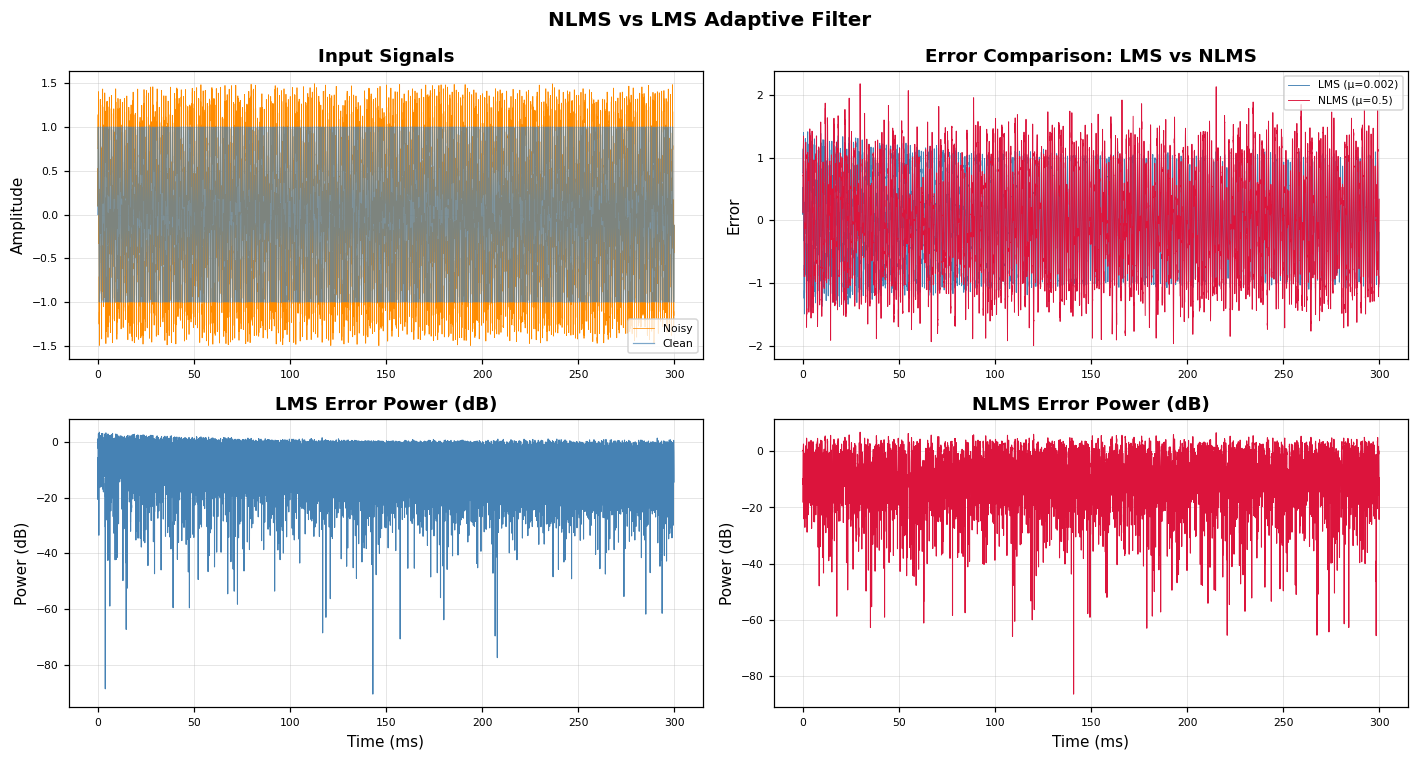

In [2]:
FS = 44100
DURATION = 0.3
FREQ = 880.0

_, clean = generate_sine(freq=FREQ, fs=FS, duration=DURATION)
_, noise = generate_white_noise(fs=FS, duration=DURATION, seed=7)

NOISE_LEVEL = 0.5
noisy = clean + NOISE_LEVEL * noise
reference = NOISE_LEVEL * noise

lms_out, lms_err, _ = lms(desired=noisy, reference=reference, filter_order=32, mu=0.002)
nlms_out, nlms_err, _ = nlms(desired=noisy, reference=reference, filter_order=32, mu=0.5)

t_ms = np.arange(len(noisy)) / FS * 1000

fig, axes = plt.subplots(2, 2, figsize=(13, 7))

axes[0, 0].plot(t_ms, noisy, linewidth=0.5, color="darkorange", label="Noisy")
axes[0, 0].plot(t_ms, clean, linewidth=0.8, color="steelblue", alpha=0.7, label="Clean")
axes[0, 0].set_title("Input Signals", fontweight="bold")
axes[0, 0].set_ylabel("Amplitude")
axes[0, 0].legend(fontsize=7)

axes[0, 1].plot(t_ms, lms_err, linewidth=0.6, color="steelblue", label="LMS (μ=0.002)")
axes[0, 1].plot(t_ms, nlms_err, linewidth=0.6, color="crimson", label="NLMS (μ=0.5)")
axes[0, 1].set_title("Error Comparison: LMS vs NLMS", fontweight="bold")
axes[0, 1].set_ylabel("Error")
axes[0, 1].legend(fontsize=7)

lms_pwr = 10 * np.log10(lms_err ** 2 + 1e-20)
nlms_pwr = 10 * np.log10(nlms_err ** 2 + 1e-20)

axes[1, 0].plot(t_ms, lms_pwr, linewidth=0.7, color="steelblue")
axes[1, 0].set_title("LMS Error Power (dB)", fontweight="bold")
axes[1, 0].set_xlabel("Time (ms)")
axes[1, 0].set_ylabel("Power (dB)")

axes[1, 1].plot(t_ms, nlms_pwr, linewidth=0.7, color="crimson")
axes[1, 1].set_title("NLMS Error Power (dB)", fontweight="bold")
axes[1, 1].set_xlabel("Time (ms)")
axes[1, 1].set_ylabel("Power (dB)")

for ax in axes.flatten():
    ax.tick_params(labelsize=7)
    ax.grid(True, linewidth=0.4, alpha=0.5)

fig.suptitle("NLMS vs LMS Adaptive Filter", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()